# Caso de Estudio: Sistemas de Recomendación Secuenciales con Redes Neuronales y LSTM (Long Short-Term Memory)

### 1. El Rol Estratégico de las Redes Neuronales y Modelos Secuenciales en las Organizaciones
En los ecosistemas digitales contemporáneos `Spotify`, `YouTube`, `TikTok` o plataformas de comercio electrónico, el comportamiento de los clientes **no es estático ni acumulativo**: es inherentemente **secuencial, dinámico y dependiente del contexto inmediato**.

> La limitación del filtrado colaborativo tradicional (SVD / Matrices): 
>- Los modelos clásicos asumen que una calificación dada hace años tiene el mismo peso que una interacción ocurrida hace cinco minutos. No capturan la evolución del gusto del consumidor, el estado anímico de la sesión actual `Session-Based Recommendation` ni el orden temporal de consumo.

> Para los sistemas de recomendación, la incorporación de Redes Neuronales Recurrentes con Memoria a Corto y Largo Plazo `Recurrent Neural Networks (Long Short-Term Memory, LSTM)` aporta ventajas directas a los resultados:
>1. **Predicción de la Siguiente Mejor Acción (`Next-Item Prediction`):** Modela la transición temporal $[C_1, C_2, C_3] \rightarrow C_4$, maximizando la probabilidad de que el usuario continúe escuchando una canción sin abandonar la aplicación (*reducción de Churn*).
>2. **Recomendación sin Identificación Previa (`Anonymous Session Recommendation`):** Permite recomendar a usuarios no registrados analizando únicamente los primeros 3 o 4 clics de su sesión actual.
>3. **Hiperpersonalización Adaptativa y Retención (`Adaptive Hyperpersonalization and Retention`, CLV):** Ajusta las sugerencias al momento del día (música de concentración versus música de fin de semana).

### 2. Arquitecturas usando modelos de ANN( Artificial Neural Network) y LSTM (Recurrent Neural Networks)

#### La Neurona Artificial y el Perceptrón Multicapa
> Una red neuronal artificial modela una combinación de características de entrada seguida de una transformación no lineal:
$$z = \sum_{j=1}^{d} w_j x_j + b = W^T X + b$$
$$a = \sigma(z)$$
> Donde $W$ representa los pesos sinápticos `weights`, $b$ el sesgo `bias` y $\sigma(\cdot)$ la función de activación `Activation Function` o de probabilidad para la predicción.

#### Redes Neuronales Recurrentes con Memoria a Corto y Largo Plazo (LSTM)
> Las RNN estándar sufren del problema de desvanecimiento o explosión del gradiente `Vanishing/Exploding Gradient` cuando la secuencia de clics o canciones es prolongada ($t > 10$). Los gradientes se anulan y la red olvida lo sucedido al inicio de la sesión.
> La arquitectura `Long Short-Term Memory` soluciona este cuello de botella al introducir una unidad de información llamada `cell` ($C_t$)** y tres compuertas reguladas `Gates`. La `LSTM cell` funciona como una memoria inteligente que recibe información nueva, consulta lo que recuerda del pasado y decide qué conservar para tomar la siguiente decisión:

1. **Compuerta de Olvido `Forget Gate` $f_t$:** Decide qué información descartar del estado anterior.
   $$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$$
2. **Compuerta de Entrada `Input Gate` $i_t$:** Decide qué nuevos patrones incorporar a la memoria.
   $$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$$
   $$\tilde{C}_t = \tanh(W_c [h_{t-1}, x_t] + b_c)$$
   $$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$
3. **Compuerta de Salida `Output Gate` $o_t$:** Determina qué parte del estado de celda se emitirá como estado oculto actual $h_t$.
   $$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$$
   $$h_t = o_t \odot \tanh(C_t)$$

```
Arquitectura del sistema de recomendación secuencial usando LSTM
                  
 Secuencia Histórica       Capa de Embeddings          Capas Recurrentes LSTM         Capa Densa (Softmax)
 ┌────────────────────┐    ┌────────────────────┐      ┌──────────────────────┐      ┌────────────────────┐
 │ Canción 1 (t-2)    │ ─► │ Vector Denso (E_1) │ ───► │ [Celda LSTM t-2]     │      │ Distribución de    │
 │ Canción 2 (t-1)    │ ─► │ Vector Denso (E_2) │ ───► │ [Celda LSTM t-1]     │ ───► │ Probabilidad sobre │
 │ Canción 3 (t)      │ ─► │ Vector Denso (E_3) │ ───► │ [Celda LSTM t] (h_t) │      │ todo el Catálogo   │
 └────────────────────┘    └────────────────────┘      └──────────────────────┘      └────────────────────┘
                                                                                                │
                                                                                                ▼
                                                                                       Predicción: Canción t+1
```

### 3. Funciones de Activación, Función de Pérdida, Forward y Backpropagation

| Concepto | Fórmula Matemática | Rol en la LSTM y en la Recomendación |
| :--- | :--- | :--- |
| **Sigmoide ($\sigma$)** | $\sigma(z) = \frac{1}{1 + e^{-z}} \in (0, 1)$ | Actúa como compuerta de filtrado binario en las *gates* de la celda LSTM (abrir o cerrar el paso de memoria). |
| **Tangente Hiperbólica ($\tanh$)** | $\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}} \in (-1, 1)$ | Modula candidatos al estado de celda y mantiene las magnitudes numéricas acotadas alrededor de cero. |
| **Rectified Linear Unit (ReLU)** | $\text{ReLU}(z) = \max(0, z)$ | Utilizada en capas densas intermedias para mitigar el desvanecimiento de gradiente y acelerar convergencia. |
| **Softmax** | $\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{C} e^{z_j}}$ | Convierte la salida final en una distribución de probabilidades válida sobre las canciones $C$ del catálogo. |

---

#### 3.1 Función de Pérdida: Entropía Cruzada Categórica (*Cross-Entropy Loss*)
Cuando modelamos la predicción de la siguiente canción como un problema multiclase sobre $C$ ítems posibles, la función de pérdida óptima es:
$$\mathcal{L}_{CE} = - \sum_{k=1}^{C} y_k \log(\hat{y}_k)$$
Donde $y_k$ es $1$ si la canción $k$ fue la reproducida y $\hat{y}_k$ es la probabilidad predicha por la red neuronal. Es decir, **penaliza severamente al recomendador si asigna baja probabilidad al ítem correcto**.

#### 3.2 Ciclo de Aprendizaje: `Forward Propagation` - `Backpropagation Through Time, (BPTT)`
1. Propagación hacia Adelante `Forward Propagation`: La secuencia ingresa por la capa de `Embeddings`, atraviesa los estados ocultos de las celdas `LSTM` paso a paso temporalmente y proyecta la distribución de salida para calcular el valor de pérdida $\mathcal{L}$.
2. Retropropagación en el Tiempo `Backpropagation Through Time, (BPTT)`: Mediante la regla de la cadena del cálculo multivariable, el algoritmo retrocede temporalmente desde $t$ hacia $t-1, t-2, \dots$, calculando las derivadas parciales $\frac{\partial \mathcal{L}}{\partial W}$ de cada matriz de pesos para actualizar los parámetros con un optimizador adaptativo como `Adam`:
   $$W^{(nuevo)} = W^{(anterior)} - \eta \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

Instale las bibliotecas de [keras](https://pypi.org/project/keras/) y [tensorflow](https://pypi.org/project/tensorflow/).

In [6]:
# Importación de bibliotecas científicas y del ecosistema TensorFlow y Keras
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers

# Configuración de estilo visual
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["font.size"] = 10
warnings.filterwarnings("ignore")

print(f"Ambiente Deep Learning configurado con TensorFlow versión: {tf.__version__}")
print(f"Dispositivos GPU detectados: {len(tf.config.list_physical_devices('GPU'))}")

Ambiente Deep Learning configurado con TensorFlow versión: 2.22.0-rc0
Dispositivos GPU detectados: 0


## 4. Ingesta y transformación de Datos

> Cargamos el catálogo de canciones de Kaggle disponible en [Music Dataset: Song Information and Lyrics](https://www.kaggle.com/datasets/suraj520/music-dataset-song-information-and-lyrics). A partir de los identificadores únicos, estructuramos sesiones de escucha temporal que simulan la interacción de clientes en una plataforma de streaming.

In [7]:
# Cargar el archivo de canciones en el repositorio o almacenamiento
data_path = "../datasets/songs.csv"

data_raw = pd.read_csv(data_path)
print(f"Catálogo musical cargado desde: {data_path}")
data_raw = pd.DataFrame(data_raw)

# Limpieza de nulos
data_raw["Name"] = data_raw["Name"].fillna("Canción Desconocida")
data_raw["Artist"] = data_raw["Artist"].fillna("Artista Varios")
data_raw["song_id"] = data_raw["Name"] + " - " + data_raw["Artist"]

print(f"Catálogo disponible: {len(data_raw):,} pistas musicales registradas.")
display(data_raw.head())

Catálogo musical cargado desde: ../datasets/songs.csv
Catálogo disponible: 799 pistas musicales registradas.


,Name,Artist,Album,Popularity,Lyrics,song_id
0,Imagine - Remastered 2010,John Lennon,Imagine,79,8 ContributorsDiscographie 2021 — Pop & Rock L...,Imagine - Remastered 2010 - John Lennon
1,A Whiter Shade Of Pale,Procol Harum,A Whiter Shade Of Pale,0,38 ContributorsA Whiter Shade of Pale Lyrics[I...,A Whiter Shade Of Pale - Procol Harum
2,My Sweet Lord,George Harrison,All Things Must Pass (Remastered),0,58 ContributorsMy Sweet Lord Lyrics[Chorus]\nM...,My Sweet Lord - George Harrison
3,God Only Knows - Mono,The Beach Boys,Pet Sounds (Original Mono & Stereo Mix),67,1 ContributorGod Only Knows (mono mix) LyricsI...,God Only Knows - Mono - The Beach Boys
4,Bridge Over Troubled Water,Simon & Garfunkel,Bridge Over Troubled Water,72,57 ContributorsBridge Over Troubled Water Lyri...,Bridge Over Troubled Water - Simon & Garfunkel


### 4.1 Construcción del Dataset de Secuencias Temporales

> Para alimentar la red neuronal recurrente se generan las sesiones `Sessions` y las ventanas `Windows` temporales:
> 1. Mapeo Categórico a Índices: Convertimos cada identificador textual de canción a un token entero continuo $i \in [0, N-1]$.
> 2. Ventana Deslizante Temporal `Sliding Window`: Si un cliente escucha las canciones en la secuencia $[S_1, S_2, S_3, S_4, S_5]$ con ventana fija $L=4$:
> - Entrada $X$: $[S_1, S_2, S_3, S_4]$
> - Etiqueta Objetivo $y$: $S_5$

In [8]:
# Codificación de canciones a índices enteros únicos
canciones_unicas = sorted(data_raw["song_id"].unique().tolist())
num_canciones = len(canciones_unicas)
song2idx = {cancion: idx for idx, cancion in enumerate(canciones_unicas)}
idx2song = {idx: cancion for idx, cancion in enumerate(canciones_unicas)}

canciones_unicas = sorted(data_raw["song_id"].unique().tolist())
num_canciones = len(canciones_unicas)
print(f"Total de canciones únicas: {num_canciones}")

# Primer elemento de song2idx (canción -> índice)
primer_song2idx = next(iter(song2idx.items()))
print(f"Primer elemento de song2idx: {primer_song2idx}")

# Primer elemento de idx2song (índice -> canción)
primer_idx2song = next(iter(idx2song.items()))
print(f"Primer elemento de idx2song: {primer_idx2song}")


Total de canciones únicas: 663
Primer elemento de song2idx: ("(I Can't Get No) Satisfaction - Mono Version / Remastered 2002 - The Rolling Stones", 0)
Primer elemento de idx2song: (0, "(I Can't Get No) Satisfaction - Mono Version / Remastered 2002 - The Rolling Stones")


In [9]:
# Simulación de trayectorias de sesiones de usuarios
np.random.seed(42)
n_sesiones = 1500
seq_length = 4  # Historial de las últimas 4 canciones para predecir la siguiente

X_data = []
y_data = []

for _ in range(n_sesiones):
    current = np.random.randint(0, num_canciones)
    sesion = [current]
    for _ in range(seq_length):
        if np.random.rand() > 0.3:
            current = (current + np.random.choice([-1, 0, 1])) % num_canciones
        else:
            current = np.random.randint(0, num_canciones)
        sesion.append(current)
    
    X_data.append(sesion[:-1])
    y_data.append(sesion[-1])

X_array = np.array(X_data, dtype=np.int32)
y_array = np.array(y_data, dtype=np.int32)

# Partición en Entrenamiento (80%) y Validación del recomendador (20%)
n_total = len(X_array)
n_train = int(0.8 * n_total)

train_X, val_X = X_array[:n_train], X_array[n_train:]
train_y, val_y = y_array[:n_train], y_array[n_train:]

print(f"Total de sesiones temporales: {n_total:,}")
print(f"Conjunto de Entrenamiento:     {train_X.shape[0]:,} secuencias de forma {train_X.shape}")
print(f"Conjunto de Validación:        {val_X.shape[0]:,} secuencias de forma {val_X.shape}")
print(f"Total de ítems del catálogo:   {num_canciones}")

Total de sesiones temporales: 1,500
Conjunto de Entrenamiento:     1,200 secuencias de forma (1200, 4)
Conjunto de Validación:        300 secuencias de forma (300, 4)
Total de ítems del catálogo:   663


## 5. Implementación del Modelo `LSTM Recomendation Model`

Construimos el modelo utilizando la API secuencial de **Keras**:
1. **`layers.Embedding`:** Representación latente densa de cada canción ($64$ dimensiones).
2. **`layers.LSTM`:** Celda recurrente de $128$ unidades que procesa la secuencia temporal y preserva dependencias de largo alcance mediante sus compuertas.
3. **`layers.Dropout`:** Apaga aleatoriamente el $20\%$ de las conexiones sinápticas para prevenir sobreajuste (*overfitting*).
4. **`layers.Dense(activation='softmax')`:** Capa de salida que genera la distribución de probabilidad completa sobre las $C$ canciones del catálogo.

In [10]:
def build_keras_lstm_recommender(vocab_size, seq_len=4, embedding_dim=64, hidden_dim=128, dropout_rate=0.2):
    model = models.Sequential([
        # 1. Capa de Embeddings (Mapeo a representación vectorial densa)
        layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, name="song_embeddings"),
        
        # 2. Capa Recurrente LSTM con compuertas de olvido, entrada y salida
        layers.LSTM(units=hidden_dim, return_sequences=False, name="lstm_recurrent_layer"),
        
        # 3. Regularización Dropout para prevenir sobreajuste
        layers.Dropout(rate=dropout_rate, name="dropout_regularization"),
        
        # 4. Capa Densa de Clasificación Multiclase con activación Softmax
        layers.Dense(units=vocab_size, activation="softmax", name="output_probabilities")
    ])
    
    # Compilación: Función de pérdida, optimizador Adam y métrica de exactitud
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.003),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

modelo_keras = build_keras_lstm_recommender(vocab_size=num_canciones, seq_len=seq_length)
modelo_keras.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ song_embeddings (Embedding)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_recurrent_layer (LSTM)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_regularization          │ ?                      │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_probabilities (Dense)    │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 6. Proceso de Entrenamiento en Keras: Forward, Backpropagation y Callbacks

Entrenamos el modelo mediante `model.fit()`, integrando el callback `EarlyStopping` para detener el entrenamiento si la pérdida de validación deja de mejorar, restaurando automáticamente los mejores pesos obtenidos.

In [11]:
# Callback de parada temprana para control de sobreajuste
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

batch_size = 64
epochs = 35

print("Iniciando ciclo de entrenamiento en Keras...")
history_keras = modelo_keras.fit(
    train_X, train_y,
    validation_data=(val_X, val_y),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[early_stopping],
    verbose=1
)

print("\nEntrenamiento de la red neuronal LSTM en Keras finalizado con éxito.")

Iniciando ciclo de entrenamiento en Keras...
Epoch 1/35
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.0075 - loss: 6.4959 - val_accuracy: 0.0100 - val_loss: 6.4974
Epoch 2/35
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0567 - loss: 6.3989 - val_accuracy: 0.0000e+00 - val_loss: 6.8583
Epoch 3/35
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0183 - loss: 6.0663 - val_accuracy: 0.0033 - val_loss: 7.5659
Epoch 4/35
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0417 - loss: 5.5497 - val_accuracy: 0.0033 - val_loss: 7.7358
Epoch 5/35
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1250 - loss: 4.6548 - val_accuracy: 0.0133 - val_loss: 7.5808
Epoch 6/35
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2858 - loss: 3.6637 - val_accuracy: 0.0100 - val_loss: 7.6754
Epoch 7/35
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4108 - loss: 2.8580 - val_accuracy: 0.0233 - val_loss: 8.3706
Epoch 8/35
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5708

## 7. Validación del Modelo con Gráficas de Función de Pérdida (*Loss*) y Exactitud (*Accuracy*)

La evaluación de las curvas generadas por `history_keras.history` permite realizar diagnósticos directivos sobre el aprendizaje:
- **Convergencia Normal:** Descenso progresivo de la pérdida tanto en entrenamiento como en validación.
- **Diagnóstico de Sobreajuste (*Overfitting*):** Si la curva de *Train Loss* continúa cayendo mientras *Val Loss* se estabiliza o sube, el modelo está memorizando las secuencias en lugar de generalizar.
- **Diagnóstico de Subajuste (*Underfitting*):** Pérdidas estancadas en magnitudes altas indican que el modelo requiere mayor capacidad o ajuste de la tasa de aprendizaje (*learning rate*).

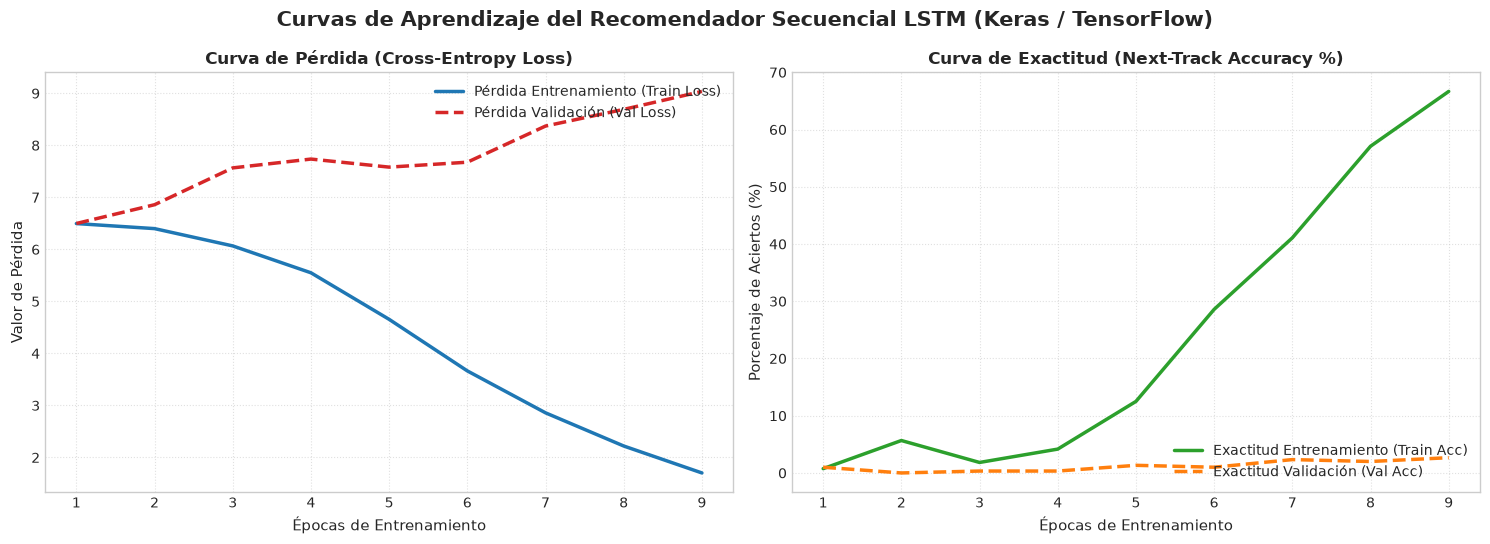

In [12]:
# Extracción de métricas registradas en el objeto History de Keras
train_loss = history_keras.history["loss"]
val_loss = history_keras.history["val_loss"]
train_acc = [acc * 100 for acc in history_keras.history["accuracy"]]
val_acc = [acc * 100 for acc in history_keras.history["val_accuracy"]]
epochs_trained = range(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle("Curvas de Aprendizaje del Recomendador Secuencial LSTM (Keras / TensorFlow)", fontsize=15, fontweight="bold")

# 1. Gráfica de Pérdida (Sparse Categorical Cross-Entropy Loss)
axes[0].plot(epochs_trained, train_loss, label="Pérdida Entrenamiento (Train Loss)", color="#1f77b4", linewidth=2.5)
axes[0].plot(epochs_trained, val_loss, label="Pérdida Validación (Val Loss)", color="#d62728", linewidth=2.5, linestyle="--")
axes[0].set_title("Curva de Pérdida (Cross-Entropy Loss)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Épocas de Entrenamiento", fontsize=11)
axes[0].set_ylabel("Valor de Pérdida", fontsize=11)
axes[0].legend(loc="upper right", fontsize=10)
axes[0].grid(True, linestyle=":", alpha=0.6)

# 2. Gráfica de Exactitud (Accuracy %)
axes[1].plot(epochs_trained, train_acc, label="Exactitud Entrenamiento (Train Acc)", color="#2ca02c", linewidth=2.5)
axes[1].plot(epochs_trained, val_acc, label="Exactitud Validación (Val Acc)", color="#ff7f0e", linewidth=2.5, linestyle="--")
axes[1].set_title("Curva de Exactitud (Next-Track Accuracy %)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Épocas de Entrenamiento", fontsize=11)
axes[1].set_ylabel("Porcentaje de Aciertos (%)", fontsize=11)
axes[1].legend(loc="lower right", fontsize=10)
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## 8. Inferencia Operativa: Sugerencia de la Lista Top-K para Producción en Tiempo Real

Simulamos el despliegue del recomendador en producción: ante el ingreso de una sesión reciente de un usuario, el modelo Keras estima las probabilidades de todo el catálogo y retorna el **Top-5 de recomendaciones** con sus niveles de confianza probabilística.

In [13]:
def recomendar_siguiente_cancion_keras(secuencia_canciones, top_k=5):
    """
    Infiere las top_k canciones recomendadas a partir de una secuencia de sesión reciente en Keras.
    """
    # Mapeo a índices enteros
    indices = [song2idx.get(c, 0) for c in secuencia_canciones[-seq_length:]]
    if len(indices) < seq_length:
        indices = [0] * (seq_length - len(indices)) + indices
        
    x_input = np.array([indices], dtype=np.int32)
    
    # Inferencia de probabilidades mediante Keras
    probabilidades = modelo_keras.predict(x_input, verbose=0)[0]
    
    # Extracción de los índices con mayor probabilidad
    top_indices = np.argsort(probabilidades)[::-1][:top_k]
    
    resultados = [
        (idx2song[idx], float(probabilidades[idx]))
        for idx in top_indices
    ]
    return resultados

# Prueba de inferencia en tiempo real con una sesión de ejemplo
sesion_ejemplo = canciones_unicas[:4]
top_predicciones = recomendar_siguiente_cancion_keras(sesion_ejemplo, top_k=5)

print("Reporte de inferencia en tiempo real (Next-Track Recommeder)")
print(f"Historial de Sesión Escuchado por el Usuario:\n" + " -> ".join(sesion_ejemplo) + "\n")
print("Top 5 Pistas Sugeridas con Probabilidad Calibrada:")
for rank, (cancion, prob) in enumerate(top_predicciones, start=1):
    print(f"{rank}. {cancion} | Confianza Probabilística: {prob * 100:.2f}%")

Reporte de inferencia en tiempo real (Next-Track Recommeder)
Historial de Sesión Escuchado por el Usuario:
(I Can't Get No) Satisfaction - Mono Version / Remastered 2002 - The Rolling Stones -> (We're Gonna) Rock Around The Clock - Single Version - Bill Haley & His Comets -> 10:35 - Tiësto -> 1979 - Remastered 2012 - The Smashing Pumpkins

Top 5 Pistas Sugeridas con Probabilidad Calibrada:
1. Na Contramão - DJ Katrip | Confianza Probabilística: 0.16%
2. Crazy - Single Version - Patsy Cline | Confianza Probabilística: 0.16%
3. Tony Soprano 2 - Nines | Confianza Probabilística: 0.16%
4. They Don't Care About Us - Michael Jackson | Confianza Probabilística: 0.16%
5. Calendar - Nines | Confianza Probabilística: 0.16%


## 9. Matriz Comparativa Estratégica: Tradicional vs. RAG vs. Deep Learning (LSTM en Keras)

| Criterio de Selección | Recomendador Tradicional (Surprise / SVD) | Recomendador Semántico (RAG / LLM) | Recomendador Secuencial (Deep Learning / LSTM) |
| :--- | :--- | :--- | :--- |
| **Naturaleza del Problema** | Calificación estática histórica ($u, i, r$). | Búsqueda por intención, lírica y emoción. | Predicción de la siguiente interacción temporal en sesión ($t \rightarrow t+1$). |
| **Dependencia del Orden Temporal** | Nula (ignora el orden cronológico). | Nula o baja. | **Máxima:** Modela la transición y el ritmo de consumo. |
| **Manejo de Sesiones Anónimas** | Inoperante (requiere ID de usuario con historial). | Posible mediante búsqueda directa. | **Excelente:** Recomienda con los primeros clics de la visita. |
| **Función de Pérdida / Métrica** | RMSE / MAE sobre calificaciones continuas. | Relevancia semántica, Cobertura, Gini. | Cross-Entropy Loss, Next-Item Accuracy %, Hit@K. |
| **Complejidad Computacional** | Muy baja en inferencia ($< 1$ ms en CPU). | Alta (Vectorial + Generación de texto). | Media (Inferencia matricial tensorial rápida en GPU/CPU). |
| **Caso de Uso en la Industria** | Recomendaciones masivas de fondo en catálogos. | Asistentes conversacionales y curaduría temática. | Listas dinámicas automáticas (*Autoplay* tipo Spotify / TikTok). |

## 10. Conclusiones y Aplicabilidad
1. **Monetización del Momento de Consumo (*Real-Time Recommenders*):** Las plataformas modernas no compiten con catálogos estáticos; generan valor capturando la intención inmediata del usuario a través de transiciones fluidas de contenido.
2. **Auditoría de Sobreajuste con Keras Callbacks:** La integración de `EarlyStopping` y la supervisión de las curvas de *Loss* y *Accuracy* previenen el despliegue de modelos sobreajustados en producción, protegiendo los recursos computacionales.
3. **Arquitecturas Híbridas Modernas:** El estándar industrial articula **SVD** para candidatos globales, **LSTM** para reordenar en tiempo real según la sesión actual, y **RAG** para redactar explicaciones transparentes que aumentan la confianza del consumidor.